# Model Training & Comparative Analysis

In questo notebook addestreremo 4 diversi modelli di classificazione sul dataset processato e li valuteremo sul **GUIDE Test Set**. 

**Obiettivo:** Identificare il modello migliore per predire se un incidente è un **True Positive** (Minaccia Reale).

**Modelli:**
1.  **Decision Tree**: Modello baseline interpretabile.
2.  **Random Forest**: Modello ensemble robusto.
3.  **XGBoost**: Gradient Boosting (spesso SOTA su dati tabulari).
4.  **Feed Forward Neural Network (MLP)**: Rete neurale multistrato.

**Strategia Anti-Leakage:**
*   Lo split Train/Validation è stato fatto **a monte** nel notebook di Feature Engineering (a livello IncidentId, PRIMA del Target Encoding).
*   `train_final_balanced.csv`: 80% degli incidenti (undersampled)
*   `val_final.csv`: 20% degli incidenti (distribuzione reale, NO leakage)
*   `test_final.csv`: GUIDE_Test (valutazione finale)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

# Modelli
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Metriche e Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Configurazioni
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')

# Percorsi
DATA_DIR = '../data/processed_final'

print("Librerie caricate.")

Librerie caricate.


## 1. Caricamento e Preparazione Dati

In [16]:
# Carichiamo i dataset generati dalla pipeline precedente (già splittati senza leakage)
print("Caricamento dati...")

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_final_balanced.csv'))
val_df = pd.read_csv(os.path.join(DATA_DIR, 'val_final.csv'))  
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_final.csv'))

# Colonne da escludere
features_to_drop = ['IncidentId', 'Target']

# Train Set (80%, bilanciato)
X_train = train_df.drop(columns=features_to_drop, errors='ignore')
y_train = train_df['Target']

# Validation Set (20%, sbilanciato - distribuzione reale)
X_val = val_df.drop(columns=features_to_drop, errors='ignore')
y_val = val_df['Target']

# Test Set (GUIDE_Test)
X_test_final = test_df.drop(columns=features_to_drop, errors='ignore')
y_test_final = test_df['Target']

# Rimuoviamo eventuali righe con Target NaN nel test set
valid_test_mask = y_test_final.notna()
X_test_final = X_test_final[valid_test_mask]
y_test_final = y_test_final[valid_test_mask]

print(f"Train Set (Balanced):  {X_train.shape}")
print(f"Validation Set:        {X_val.shape}")
print(f"Test Set (Hold-out):   {X_test_final.shape}")

Caricamento dati...
Train Set (Balanced):  (232664, 38)
Validation Set:        (26022, 38)
Test Set (Hold-out):   (236267, 38)


### 1.1 Scaling
Le reti neurali richiedono dati scalati. Gli alberi non ne hanno bisogno, ma non ne soffrono. Scaliamo tutto per uniformità.

**Nota:** Lo split Train/Validation è già stato eseguito nel notebook di Feature Engineering per evitare data leakage nel Target Encoding.

In [17]:
# Scaling (fit su train, transform su val e test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

print("Dati scalati.")
print(f"Train samples: {X_train.shape[0]}")
print(f"Val samples:   {X_val.shape[0]}")
print(f"Test samples:  {X_test_final.shape[0]}")

Dati scalati.
Train samples: 232664
Val samples:   26022
Test samples:  236267


## 2. Addestramento Modelli

In [18]:
# Dizionario per salvare i modelli addestrati e i risultati
models = {}
results = {}

def train_and_evaluate(name, model, X_tr, y_tr, X_v, y_v):
    print(f"\nAddestramento {name}...")
    model.fit(X_tr, y_tr)
    
    # Predizioni su Validation
    preds = model.predict(X_v)
    probs = model.predict_proba(X_v)[:, 1]
    
    print(f"{name} - Validation F1: {f1_score(y_v, preds):.4f}")
    print(f"{name} - Validation AUC: {roc_auc_score(y_v, probs):.4f}")
    
    return model

### 2.1 Decision Tree

In [19]:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
models['DecisionTree'] = train_and_evaluate('DecisionTree', dt_model, X_train, y_train, X_val, y_val)


Addestramento DecisionTree...
DecisionTree - Validation F1: 0.8069
DecisionTree - Validation AUC: 0.8978


### 2.2 Random Forest

In [20]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
models['RandomForest'] = train_and_evaluate('RandomForest', rf_model, X_train, y_train, X_val, y_val)


Addestramento RandomForest...
RandomForest - Validation F1: 0.8249
RandomForest - Validation AUC: 0.9155


### 2.3 XGBoost

In [21]:
xgb_model = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.1, 
    max_depth=6, 
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)
models['XGBoost'] = train_and_evaluate('XGBoost', xgb_model, X_train, y_train, X_val, y_val)


Addestramento XGBoost...
XGBoost - Validation F1: 0.8268
XGBoost - Validation AUC: 0.9158


### 2.4 Feed Forward Neural Network (MLP)

In [22]:
# Usiamo MLPClassifier di Sklearn per semplicità
# Architettura: 2 layer nascosti (128, 64 neuroni)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64), 
    activation='relu', 
    solver='adam', 
    alpha=0.0001, 
    batch_size=256,
    learning_rate_init=0.005,
    max_iter=50,
    random_state=42,
    early_stopping=True
)

# Nota: per MLP usiamo i dati scalati
models['MLP'] = train_and_evaluate('MLP', mlp_model, X_train_scaled, y_train, X_val_scaled, y_val)


Addestramento MLP...
MLP - Validation F1: 0.7968
MLP - Validation AUC: 0.8917


## 3. Valutazione Finale su GUIDE_Test

Ora testiamo i modelli sul dataset di test reale (`GUIDE_Test`), che non hanno mai visto.

In [23]:
final_metrics = []

print("Valutazione sul Test Set Finale (GUIDE_Test)...")

for name, model in models.items():
    # Scegli il dataset corretto (scalato per MLP, normale per altri)
    X_target = X_test_scaled if name == 'MLP' else X_test_final
    
    # Predizioni
    y_pred = model.predict(X_target)
    y_prob = model.predict_proba(X_target)[:, 1]
    
    # Calcolo Metriche
    acc = accuracy_score(y_test_final, y_pred)
    prec = precision_score(y_test_final, y_pred)
    rec = recall_score(y_test_final, y_pred)
    f1 = f1_score(y_test_final, y_pred)
    auc = roc_auc_score(y_test_final, y_prob)
    
    final_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc
    })
    
    # Salva predizioni per analisi successive
    results[name] = {'y_pred': y_pred, 'y_prob': y_prob}

# Tabella Comparativa
metrics_df = pd.DataFrame(final_metrics).set_index('Model')
print("\n--- Risultati Finali ---")
display(metrics_df.style.background_gradient(cmap='viridis', axis=0))

Valutazione sul Test Set Finale (GUIDE_Test)...

--- Risultati Finali ---


,Accuracy,Precision,Recall,F1-Score,AUC
Model,,,,,
DecisionTree,0.765473,0.520855,0.799034,0.630630,0.881878
RandomForest,0.808369,0.588307,0.783425,0.671989,0.899464
XGBoost,0.795532,0.564487,0.805132,0.663668,0.898810
MLP,0.783664,0.550088,0.750046,0.634691,0.874095


## 4. Visualizzazioni e Confronto

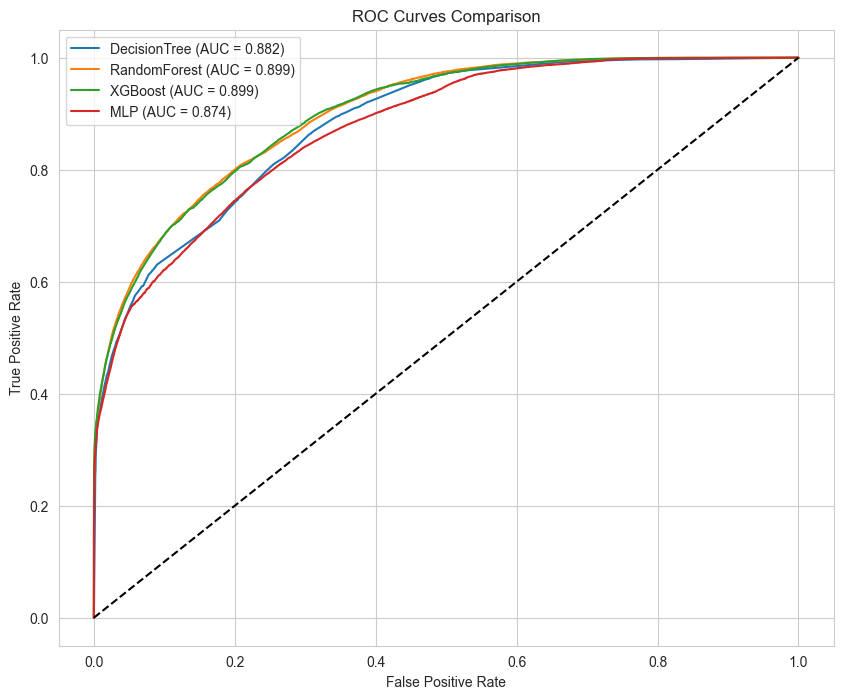

In [24]:
# 1. ROC Curves
plt.figure(figsize=(10, 8))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test_final, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test_final, res['y_prob']):.3f})")

plt.plot([0, 1], [0, 1], 'k--', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

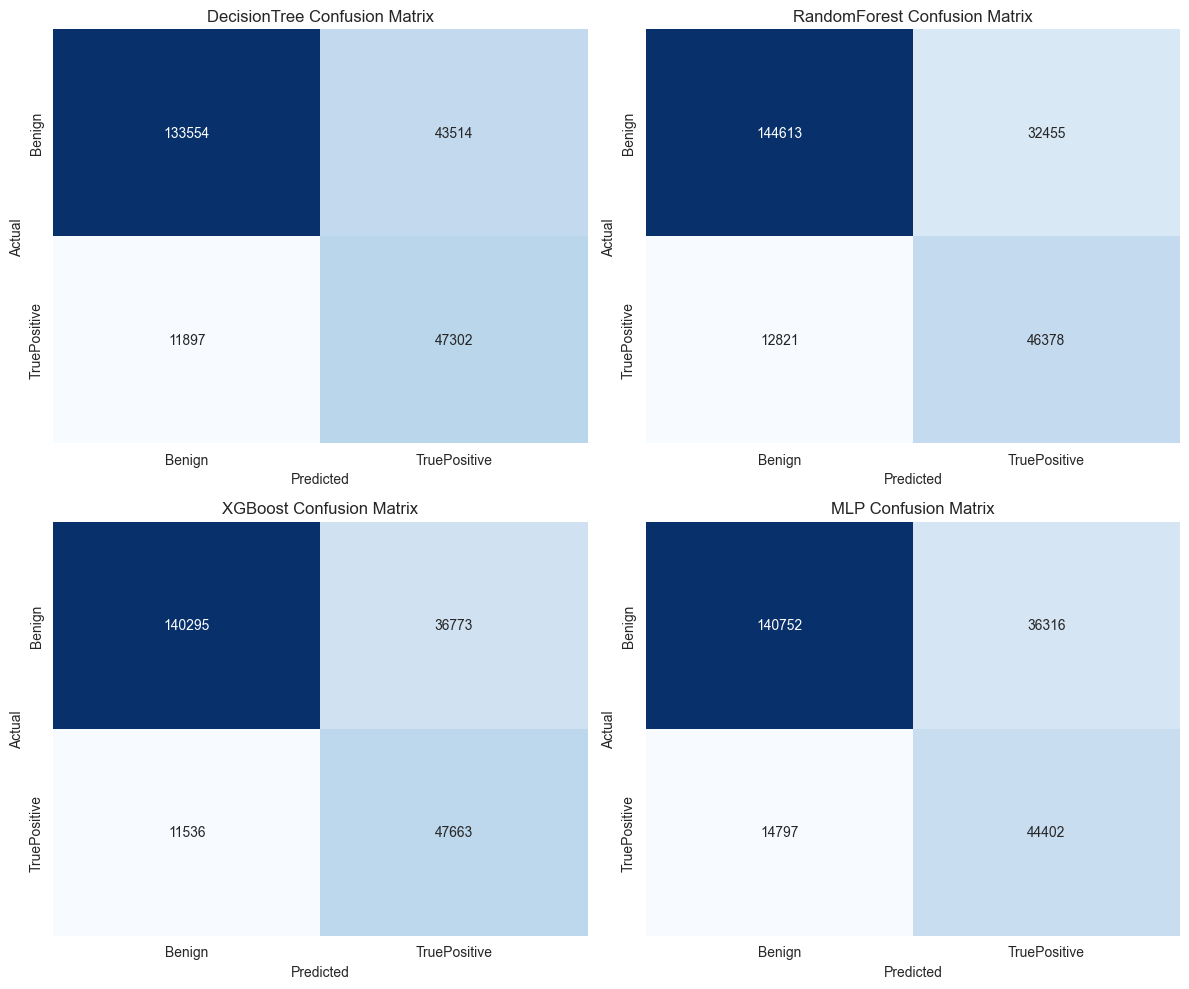

In [25]:
# 2. Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test_final, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_xticklabels(['Benign', 'TruePositive'])
    axes[i].set_yticklabels(['Benign', 'TruePositive'])

plt.tight_layout()
plt.show()

## 5. Feature Importance (XGBoost)
Vediamo quali feature sono state più determinanti per il modello migliore (spesso XGBoost).

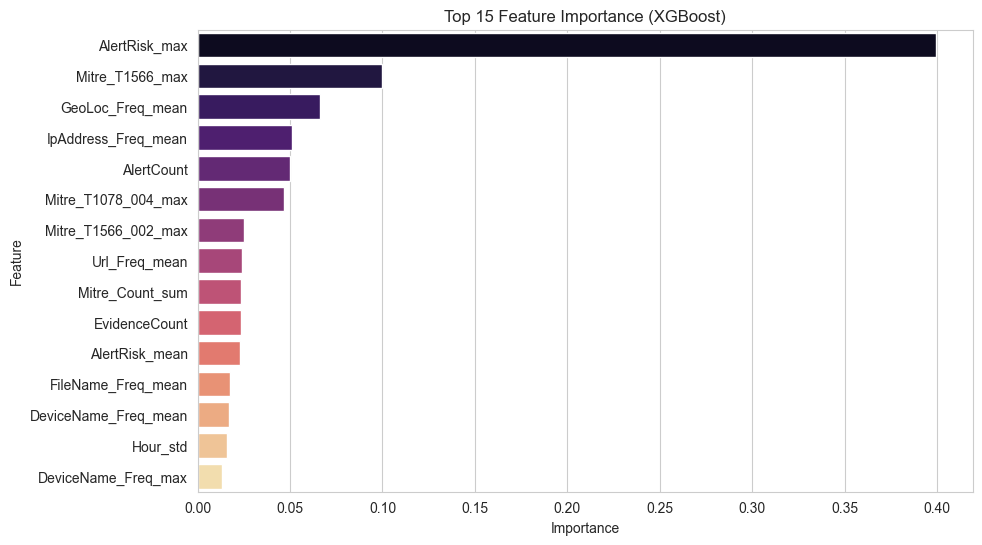

In [26]:
importance = models['XGBoost'].feature_importances_
feat_names = X_train.columns

feat_imp = pd.DataFrame({'Feature': feat_names, 'Importance': importance})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')
plt.title('Top 15 Feature Importance (XGBoost)')
plt.show()

# MLP con torch

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

# 1. Rilevamento Hardware (GPU/MPS/CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"🎮 Utilizzo GPU NVIDIA: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("🍎 Utilizzo Accelerazione Apple Silicon (MPS)")
else:
    device = torch.device('cpu')
    print("💻 GPU non rilevata, utilizzo CPU")
# 2. Definizione dell'Architettura della Rete (MLP)
class IncidentMLP(nn.Module):
    def __init__(self, input_dim):
        super(IncidentMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),  # Primo Layer
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),            # Regolarizzazione per evitare overfitting

            nn.Linear(128, 64),         # Secondo Layer
            nn.ReLU(),
            nn.BatchNorm1d(64),

            nn.Linear(64, 32),          # Terzo Layer
            nn.ReLU(),
            nn.BatchNorm1d(32),

            nn.Linear(32, 1)            # Output (Logit per classificazione binaria)
        )

    def forward(self, x):
        return self.layers(x)

# 3. Preparazione dei Dati (Usando i dati scalati creati in precedenza nel notebook)
# Assumiamo che X_train_scaled e y_train siano pronti
X_train_t = torch.FloatTensor(X_train_scaled).to(device)
y_train_t = torch.FloatTensor(y_train.values).view(-1, 1).to(device)

X_test_t = torch.FloatTensor(X_test_scaled).to(device)
y_test_t = torch.FloatTensor(y_test_final.values).view(-1, 1).to(device)
# Creazione del DataLoader per il training batch
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)

# 4. Inizializzazione Modello, Funzione di Loss e Ottimizzatore
model_pt = IncidentMLP(X_train_t.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()  # Ideale per classificazione binaria
optimizer = optim.Adam(model_pt.parameters(), lr=0.01)

# 5. Training Loop
epochs = 50
print("\n--- Inizio Addestramento PyTorch ---")
for epoch in range(epochs):
    model_pt.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_pt(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoca [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

# 6. Valutazione sul Hold-out Set (GUIDE_Test)
model_pt.eval()
with torch.no_grad():
    # Otteniamo i logit e applichiamo la sigmoide per le probabilità
    logits = model_pt(X_test_t)
    probs_pt = torch.sigmoid(logits).cpu().numpy().flatten()
    preds_pt = (probs_pt > 0.5).astype(int)

# 7. Risultati Finali
f1 = f1_score(y_test_final, preds_pt)
auc = roc_auc_score(y_test_final, probs_pt)
acc = accuracy_score(y_test_final, preds_pt)

print("\n" + "="*30)
print("RISULTATI FINALI PYTORCH (GPU)")
print("="*30)
print(f"Accuracy:  {acc:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC AUC:   {auc:.4f}")

🎮 Utilizzo GPU NVIDIA: NVIDIA GeForce RTX 3060 Ti

--- Inizio Addestramento PyTorch ---
Epoca [10/50], Loss: 0.3797
Epoca [20/50], Loss: 0.3742
Epoca [30/50], Loss: 0.3704
Epoca [40/50], Loss: 0.3686
Epoca [50/50], Loss: 0.3665

RISULTATI FINALI PYTORCH (GPU)
Accuracy:  0.7837
F1-Score:  0.6354
ROC AUC:   0.8784
